# Level 1 - Data Analysis Tasks
Dataset used: `Dataset  (1).csv`

This notebook contains all Level 1 tasks from the Cognifyz internship project.

In [33]:
# Fist we are just loading the important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
# Now we will lode the datset
df = pd.read_csv('Dataset  (1).csv')

In [35]:
#  weare simply checking the dataset like what kind of columns and other details it have 
df.sample(5)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
3417,8453,Grillz,1,New Delhi,"G3A, Ground Floor, District Centre, Janakpuri,...","District Centre, Janakpuri","District Centre, Janakpuri, New Delhi",77.081372,28.630143,Fast Food,...,Indian Rupees(Rs.),No,Yes,No,No,2,2.5,Orange,Average,85
554,17697418,Chapala,216,Waterloo,"900 La Porte Road, Waterloo, IA 50702",Waterloo,"Waterloo, Waterloo",-92.323032,42.477281,Mexican,...,Dollar($),No,No,No,No,2,3.6,Yellow,Good,69
1912,18393717,Baskin Robbins,1,Gurgaon,"Shop 1, Plot 1-A, Circular Road, New Colony, S...",Sector 39,"Sector 39, Gurgaon",77.017664,28.467220,Ice Cream,...,Indian Rupees(Rs.),No,No,No,No,1,0.0,White,Not rated,0
3036,18247029,GoGourmet,1,New Delhi,"18-20, Hindustan Times Buliding, KG Marg, Conn...",Connaught Place,"Connaught Place, New Delhi",77.223175,28.627897,"Healthy Food, Beverages",...,Indian Rupees(Rs.),No,Yes,No,No,2,3.7,Yellow,Good,55
195,17330735,Samurai Japanese Cuisine & Sushi Bar,216,Columbus,"1009 Broadway, Columbus, GA 31901",Columbus,"Columbus, Columbus",-84.993363,32.465242,"Japanese, Steak, Sushi",...,Dollar($),No,No,No,No,3,3.6,Yellow,Good,109


In [36]:
# now we will checking is there any null values in our dataset
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [37]:
# Now we will check is there any duplicate values in our dataset
df.duplicated().sum()

np.int64(0)

#### Level 1 Task

Task 1:-
- we need to Determine the top three most common cuisines in the dataset.

Top 3 Most Common Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


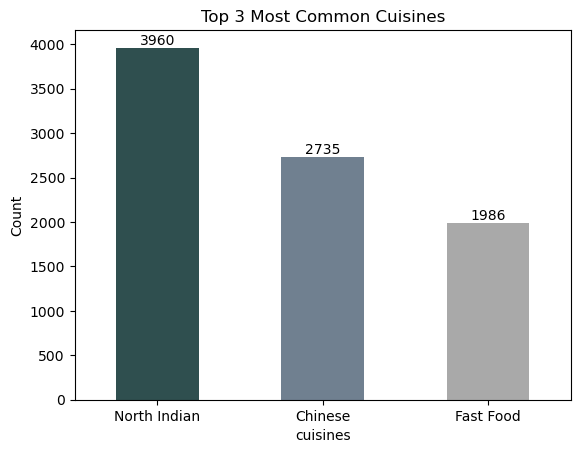

In [61]:

cuisines = df['Cuisines'].str.split(', ')#Here we are Separating the values wherever there is a comma using string split method 
all_cuisines = cuisines.explode() # here we are breaking down the list of cuisines into individual rows

top_cuisines = all_cuisines.value_counts().head(3)# Here we are counting how many times each value appears.

print('='*50)
print("Top 3 Most Common Cuisines:") 
print('='*50)
print(top_cuisines)# Now we are printing each values
print('='*50)


# Now we will see the same Data visually using bar graph for better understanding
plt.Figure(figsize=(10,6))
ax=top_cuisines.plot(kind='bar',color=['darkslategray','slategray','darkgray'])

ax.bar_label(ax.containers[0])

plt.title('Top 3 Most Common Cuisines')
plt.xlabel('cuisines')
plt.ylabel('Count')
plt.xticks(rotation=360)
plt.show()

- Now we need to Calculate the percentage of restaurants that serve each of the top cuisines

Percentage of Restaurants Serving Top Cuisines:
Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64


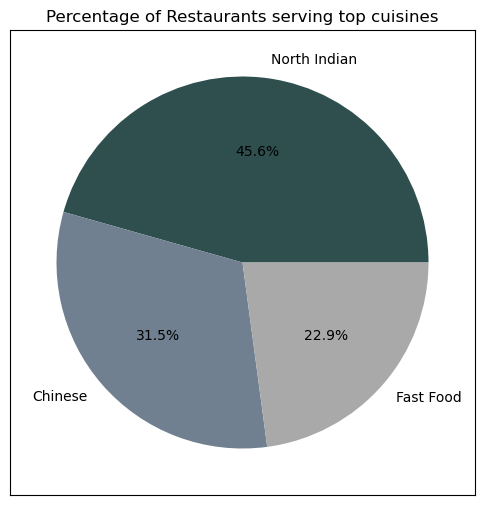

In [68]:

# Percentage calculation
percentage = (top_cuisines / len(df)) * 100
print('='*50)
print("Percentage of Restaurants Serving Top Cuisines:")
print('='*50)
print(percentage)
print('='*50)



# Now we will see the same data visually using pie chart for better understanding
plt.figure(figsize=(6,8))
plt.pie(top_cuisines.values,
        labels=top_cuisines.index,
        autopct='%1.1f%%',
        colors=['darkslategray','slategray','darkgray'])
plt.title('Percentage of Restaurants serving top cuisines')
plt.box(True)
plt.show()

- Task 2

-- Now we need to identify the city with the highest number of restaurants

In [40]:
# City with highest number of restaurants
top_city = df['City'].value_counts().idxmax()
top_city_count = df['City'].value_counts().max()

print("City with highest number of restaurants:")
print(top_city, "-", top_city_count)

# Average rating by city
city_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

print("\nAverage Rating by City:")
print(city_rating.head())

# City with highest average rating
print("\nCity with highest average rating:")
print(city_rating.idxmax(), "-", city_rating.max())


City with highest number of restaurants:
New Delhi - 5473

Average Rating by City:
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Name: Aggregate rating, dtype: float64

City with highest average rating:
Inner City - 4.9


## Task 3 - Price Range Distribution

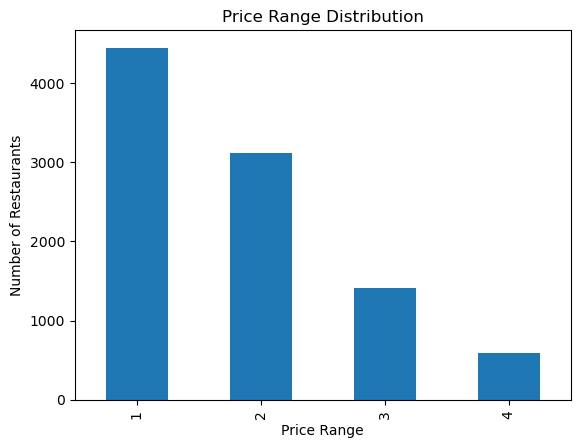

Percentage of Restaurants in Each Price Range:
Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


In [41]:
# Count price ranges
price_counts = df['Price range'].value_counts().sort_index()
price_labels = {
    1: '1 - Low',
    2: '2 - Medium',
    3: '3 - High',
    4: '4 - Very High'
}
price_counts_labeled = price_counts.rename(index=price_labels)

# Plot bar chart
ax = price_counts_labeled.plot(kind='bar', color=['slategray'])
ax.bar_label(ax.containers[0])
plt.title('Price Range Distribution')
plt.xlabel('Price Range')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.show()

# Percentage
price_percentage = (price_counts / len(df)) * 100

print("Percentage of Restaurants in Each Price Range:")
print(price_percentage)


## Task 4 - Online Delivery

In [42]:
# Percentage offering online delivery
online_delivery = df['Has Online delivery'].value_counts()

percentage_online = (online_delivery / len(df)) * 100

print("Percentage of Restaurants with Online Delivery:")
print(percentage_online)

# Average ratings comparison
rating_comparison = df.groupby('Has Online delivery')['Aggregate rating'].mean()

print("\nAverage Ratings Comparison:")
print(rating_comparison)


Percentage of Restaurants with Online Delivery:
Has Online delivery
No     74.337766
Yes    25.662234
Name: count, dtype: float64

Average Ratings Comparison:
Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64
